# Project 3: Understanding data representation through low-dimensional projections (subspace learning)
## Regardless of the level you are in this course, you are NOT allowed to use import tools from the scipy or sci-kit learn.  The only imports allowed on this project are pandas, numpy, and matplotlib (or plotly/seaborn if you prefer).

### Name: Jonathan Brown & Dyl Nebrida
### Course Level: CSC 448

## Due: Monday March 23, 2026

**Introduction:**
* In this project, we explore the application of classification using: a) Principal Componenet Analysis (PCA) and b) Linear Discriminant Analysis (LDA). The project will be broken into sections in which students registered for CSC 448 will complete sections A, B, and C, while the CSC 548 students will complete all sections.

**Objectives:**
* The objective of this project is to implement dimensionality reduction techniques before subsequent classification.

## All Students

* The first problem we aim to design a pose (orientation) estimator for a set of image data.  Please download the Boat.zip file from the D2L project 3 module.

**Problem A (60pts)**

1 (5pts). The first thing you'll need to do is read the image data in and construc the image data matrix $X = [\textbf{x}_1, \textbf{x}_2, \cdots, \textbf{x}_n]$ where each column of $X$ is a "row-scanned" image
$$
    \textbf{x}_i = \text{vec}(I_i) \in \mathbb{R}^{m}
$$
where $m$ is the number of pixels in the image (i.e., turn the image into a single column vector - hint: np.reshape works here)

For this particular dataset, there are $n=128$ images sampled at a different orientation around a single degree of freedom (i.e, the object being rotated around a single axis through 360 degrees).  Each image $I \in [0,1]^{h \times v}$ where $h=v=128$ and $m=16,384$ features.  

* This will result in a image data matrix $X \in \mathbb{R}^{16,384 \times 128}$

**Note:** The .zip also contains the Testing Set (same object imaged at random angles around the same single degree of freedom) along with a .txt file providing the actual pose (orientation) of each training image.

In [1]:
# Read in the data (however you prefer), and Construct the Image data matrix X #
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

train_folder = "Boat/Train/UnProcessed"

image_files = [f for f in os.listdir(train_folder) if f.endswith(('.png'))]

image_files.sort()

# Get image size
first_img = Image.open(os.path.join(train_folder, image_files[0]))
img_size = first_img.size  # (width, height)
num_pixels = img_size[0] * img_size[1]

# Initialize X
X = np.zeros((num_pixels, len(image_files)), dtype=np.float32)

# Loop over images and fill X
for idx, img_file in enumerate(image_files):
    img_path = os.path.join(train_folder, img_file)
    img = Image.open(img_path).convert('L')
    img_array = np.array(img, dtype=np.float32).flatten()
    X[:, idx] = img_array

print(f"X shape: {X.shape}")

X shape: (16384, 128)


2 (5pts). Next, we need to ensure the data is centered, so we subtract the mean image vector $\bar{\textbf{x}}$ from each image in the dataset.  Keep this for later classification! Write a function called CenterData that takes the original $X$ and returns the centered $X$ (referred to as $\bar{X}$) along with the mean vector $\bar{\textbf{x}}$ associated with $X$.

In [2]:
# Make sure the data is centered #
def CenterData(X):
    mean_x = np.mean(X, axis = 1, keepdims=True)
    barX = X - mean_x
    return barX, mean_x

3 (10pts). We will need a way to "select" the optimum subspace dimension (i.e., how many principal components to keep).  One way to do this is to use the information recovery ratio defined as:
$$
    \rho(\bar{X},\mu) = \frac{\sum_{i=1}^k \sigma_i^2}{\| \bar{X} \|^2_F} \leq \mu
$$
where $\mu \in [0,1]$ is the amount of information recovered from a $k$-dimensional subspace (note $\rho \rightarrow 1$ as $k \rightarrow n$) resulting in 100\% recovery and $\sigma_i$ is the $i^{\textbf{th}}$ singular value of $\bar{X}$.

* Write a function called InfoRecov that takes the \underline{centered} image data matrix $\bar{X}$, the mean vector $\bar{\textbf{x}}$, and user specified information recovery $\mu$ that returns the value $k$ required to acheive the user-specified information recovery.


**Note:** Generally $\mu=0.85 - 0.9$ is sufficient for good classification.

In [3]:
# Information Recovery #
def InfoRecov(barX,mean_x,mu):
    U, S, VT = np.linalg.svd(barX, full_matrices=False)

    varience = S**2
    totalVarience = np.sum(varience)
    averageVarience = np.cumsum(varience) / totalVarience

    k_keep = np.searchsorted(averageVarience, mu) + 1
    return k_keep

4 (20pts). Next write a function (called PCA) that takes the image data matrix $\bar{X}$, and user specified accuracy $\mu$, to compute and return the first $k$ principal components of $\bar{X}$ where $k$ is the subspace dimension required to acheive an information recovery $\mu$.  

**Note:** You will need to use the above "helper" functions to:

1. Ensure the data is centered prior to computation
2. Compute how many pricipal components to keep via the user specified information recovery $\mu$

In [4]:
# Function to compute principal component analysis #
def PCA(X_bar,mu):
    if mu is None:
        barX, meanX = CenterData(X_bar)
    else:
        barX = X_bar - mu
        meanX = mu
        
    U, S, VT = np.linalg.svd(barX, full_matrices=False)
    keep = InfoRecov( barX, meanX, mu )
    u_pca = U[:, :keep]

    return u_pca


5 (10pts). Next write a function called DataProjection that takes the first $k$ principal components, the centered data matrix $\bar{X}$, and computes the change of basis $Y$ embedding the data into a $k$-dimensional subspace.  To illustrate your function is working, generate a $k=3$-dimensional plot showing the low-dimensional embedding in $\mathbb{R}^3$.

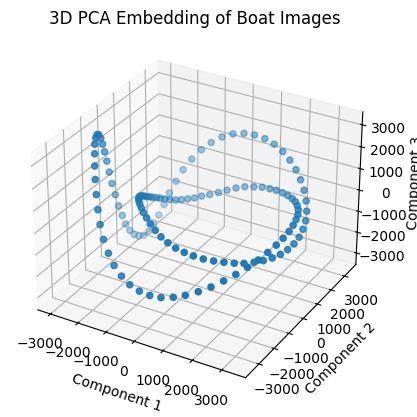

In [5]:
# Data Projection #
def DataProjection(barX,u_pca):
    T = u_pca.T
    Y_embed = T @ barX


    return Y_embed

barX, meanX = CenterData(X)

U, S, VT = np.linalg.svd(barX, full_matrices=False)

# First 3 principal components
k = 3
u_pca = U[:, :k]

Y = DataProjection(barX, u_pca)

# Extract coordinates
x = Y[0, :]
y = Y[1, :]
z = Y[2, :]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(x, y, z)

ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_zlabel("Component 3")
ax.set_title("3D PCA Embedding of Boat Images")

plt.show()

6 (10pts). Evaluate how well your low-dimensional projection works by estimating the pose of each image in the Test Set.  You may want to write a quick helper function here but it's not required.  The process for evaluation is as follows:

1. Vectorize a test image and subtract the mean computed above $\bar{\textbf{x}}$.
2. Project the test image onto the low-dimensional subspace (performa a change of basis $\textbf{t}=U_k^T \textbf{f}$) where $U_k \in \mathbb{R}^{m \times k}$ contains the first $k$ principal components, $\textbf{f} \in \mathbb{R}^m$ is the mean-centered vectorized image, and $\textbf{t} \in \mathbb{R}^k$ is the low-dimensional projection.
3. Perform a nearest-neighbor search with all other samples in $Y$ to compute which sample in $Y$ that $\textbf{t}$ is closest to.  
4. Use the equation $est = \frac{2 \pi i}{n}$ to estimate the orientation of the test sample (where $i$ is the closest sample to $\textbf{t}$)
5. Compute the estimation error by looking at the .txt file to determine the "true" orientation and subtracting the two.
6. Do this for all 64 test samples to determine the average classification error and standard deviation across the testing set.

In [6]:
# Perform pose estimation and return the estimation results (mean and standard deviation) #
barX, meanX = CenterData(X)

# SVD
U, S, VT = np.linalg.svd(barX, full_matrices=False)

k = InfoRecov( barX, meanX, 0.9)
u_pca = U[:, :k]

# Project training data
Y_lda_train = DataProjection(barX, u_pca)

angles_path = "Boat/Test/RandAng.txt"

with open(angles_path, 'r') as f:
    angles = f.read().strip().split(',')

# Convert to float
true_angles = np.array([float(a) for a in angles])

test_folder = "Boat/Test/Boat32/UnProcessed"

errors = []

n = Y_lda_train.shape[1]

for i in range(64):
    img_name = f"img_{i}.png"
    img_path = os.path.join(test_folder, img_name)
    
    img = Image.open(img_path).convert('L')
    img_vec = np.array(img, dtype=np.float32).flatten().reshape(-1, 1)
    
    bar_img = img_vec - meanX
    
    y_test = u_pca.T @ bar_img
    
    diffs = Y_lda_train - y_test
    dists = np.linalg.norm(diffs, axis=0)
    
    nn_index = np.argmin(dists)
    
    est_angle = 2 * np.pi * nn_index / n
    
    true_angle = true_angles[i]
    
    error = est_angle - true_angle
    
    error = (error + np.pi) % (2 * np.pi) - np.pi
    
    errors.append(error)
    
errors = np.array(errors)

mean_error = np.mean(errors)
std_error = np.std(errors)

print("Mean Error:", mean_error)
print("Standard Deviation of Error:", std_error)

Mean Error: 1.1954563015340836
Standard Deviation of Error: 0.6070221388789809


**Problem B (40pts)**


1 (5pts). Next, let's look at a multi-class problem and compute a linear subspace (change of basis) by exploring Linear Discriminant Analysis.  

Here, we want to investigate the fashion MNIST dataset.  Let's go ahead and get the dataset loaded (60,000 training images and 10,000 testing images) consisting of different types of clothing (shoes, shirts, etc.)

**The data can be explore** [Here](https://www.openml.org/search?type=data&sort=runs&id=40996&status=active)

- The data comes in as a 70,000 x 784 matrix, you'll need to split the dataset into a 60,0000 train/10,000 test set (stratified to make sure you get enough examples across all classes)
- These are also images (size: $28 \times 28$) but have already been vectorized into a 784-dimensional vector.


Let's also plot a sample from each of the 10 classes.  Create a 2 x 5 subplot displaying one image from each class - along with the class label above each image.

**Note:** When displaying images you need to provide a colormap, these are grayscale images so our colormap will be 'gray'

* $\texttt{plt.imshow(I,cmap='gray')}$ should work.

In [29]:
# load fashion MNIST data (you may need to install openml) #
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

# Fetch Fashion-MNIST
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)

# Extract data and targets
X, t = fashion_mnist.data, fashion_mnist.target
print('X shape:', X.shape)
print('X type:', type(X))

# Optional: Convert targets to integer
t = t.astype(np.int8)
print('t type:', type(t))

# Normalize data (pixel values 0-255 to 0-1)
X = X / 255.0

X shape: (70000, 784)
X type: <class 'numpy.ndarray'>
t type: <class 'numpy.ndarray'>


In [52]:
# create a stratified test/train set #

rng = np.random.default_rng(seed=448)

# group indices of each unique target
indices = [np.where(t == i)[0] for i in range(10)]

# concatenate indices of train set 
train_idx = np.concatenate([i[:6000] for i in indices])
# concatenate indices of test set
test_idx = np.concatenate([i[6000:] for i in indices])

# shuffle indices so classes aren't consecutive
rng.shuffle(train_idx)
rng.shuffle(test_idx)

# map to final variables
x_train, x_test = X[train_idx], X[test_idx]
t_train, t_test = t[train_idx], t[test_idx]

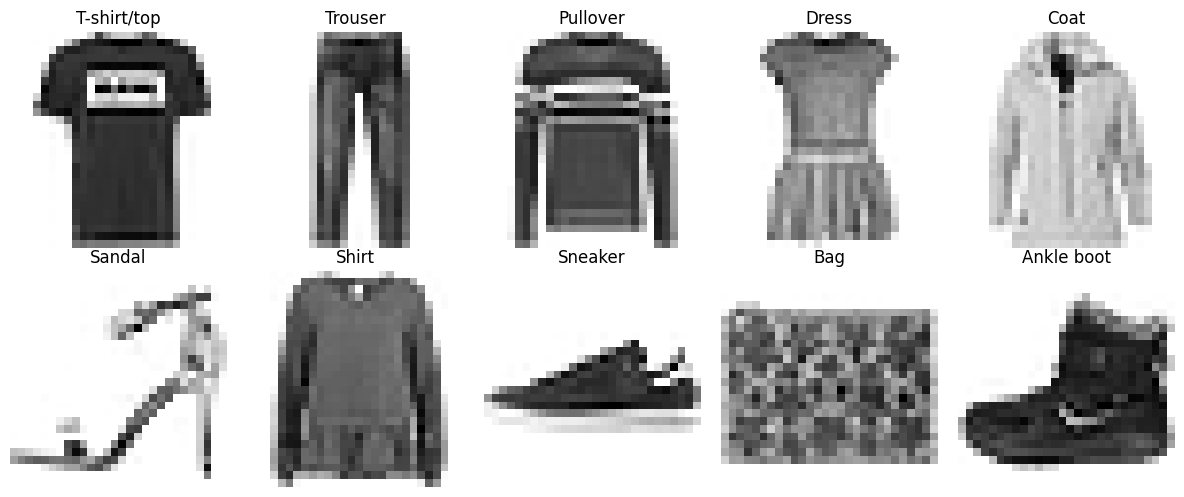

In [9]:
# Create a subplot showing one image from each class along with the associated class label #

# Fetch data
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X, t = fashion_mnist.data, fashion_mnist.target
t = t.astype(int)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(12, 5))

for i in range(10):
    # Find index of the first occurrence of class i
    index = np.where(t == i)[0][0]
    
    # Reshape the flat 784 vector back to 28x28
    img = X[index].reshape(28, 28)
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='binary')
    plt.title(class_names[i])
    plt.axis('off') 

plt.tight_layout()
plt.show()

2 (30pts). Similar to the above problem A, write a function called LDA that takes the image data matrix (this can be sorted by class to make your life easier) and the number of classes and returns the $C-1$-dimensional change of basis that maximizes:
$$
    J(\textbf{w}) = \frac{\textbf{w}^T S_b \textbf{w}}{\textbf{w}^T S_w \textbf{w}}
$$
where $S_w$ is the $\textbf{within-class}$ scatter matrix and $S_b$ is the $\textbf{between-class}$ scatter matrix.

In [82]:
# Perform multiclass logistic regression #
def LDA(x_data,c_classes):
    n = x_data.shape[1]

    ## sort by class 
    sort_indices = np.argsort(c_classes) # grab sorted indices
    c_classes = c_classes[sort_indices] # reassign with indices sorted
    x_data = x_data[sort_indices] # ressign with indices sorted
    
    # compute overall mean
    mean = np.mean(x_data, axis=0)

    S_w = np.zeros((n,n))
    S_b = np.zeros((n,n))
    ## compute within-class matrix and between-class matrix
    for i in range(0, len(x_data), 1000):
        c_samples = x_data[i:i + 1000] # grab class samples
        c_mean = np.mean(c_samples, axis=0)    # grab class mean
        #print('c_mean', c_mean)

        # compute within-class scatter matrix
        temp1 = c_samples - c_mean
        S_w += temp1.T @ temp1

        # compute between-class scatter matrix
        c_n = c_samples.shape[0]
        temp2 = (c_mean - mean).reshape(-1, 1)
        S_b += c_n * (temp2 @ temp2.T) 

    S_w += np.eye(n) * 1e-6 # add noise for stability

    A_mat = np.linalg.inv(S_w) @ S_b
    eig_vals, eig_vecs = np.linalg.eig(A_mat)

    # sort eig vals and eig vecs in descending order
    idx = np.argsort(eig_vals)[::-1]
    eig_vecs = eig_vecs[:, idx]

    # return top c - 1 eigenvectors
    num_components = len(np.unique(c_classes)) - 1
    print(num_components)
    w = eig_vecs[:, :num_components]

    return w.real

LDA(x_train, t_train)


9


array([[-6.61092477e-01,  1.97216648e-01, -3.87657140e-01, ...,
        -8.48640067e-01, -7.63543364e-01,  9.31664665e-01],
       [ 5.61821650e-01,  3.21724116e-03,  5.64914453e-01, ...,
        -2.36508651e-01,  4.45643078e-01, -3.34170863e-01],
       [-2.66920759e-01, -1.39563605e-01, -4.41290644e-01, ...,
         1.42573047e-01, -1.21384246e-01,  8.48979785e-02],
       ...,
       [ 4.06508640e-04, -1.39049235e-02, -1.01053992e-02, ...,
         1.16352791e-02,  1.34865287e-02,  8.98514106e-03],
       [ 3.94270530e-03,  2.46548431e-02, -5.29970439e-03, ...,
         5.39549577e-02, -2.39279539e-02, -2.94656222e-03],
       [ 1.43472976e-02, -2.81487947e-02, -6.88844518e-03, ...,
         9.67482794e-03,  5.47318822e-02,  3.40621036e-03]],
      shape=(784, 9))

3 (10pts). To investigate the how well the LDA classifier works, let's use the testing set to determine the classification rates for:

* The entire test set of images across class 0 - 9
* The classification rate for each individual class label (this will give you a feel for which representations are easier for the model to classify)

In [11]:
# Evaluate Performance #

**Problem C (10pts)**
* In Problems A & B, you investigated two different dimensionality reduction techniques, apply the PCA technique to the fashion MNIST dataset, using a 2-dimensional subspace, create a subplot showing the PCA projection (left) and LDA projection (right).  Use a colorbar to deleniate between the different class labels.



NameError: name 'X_train' is not defined

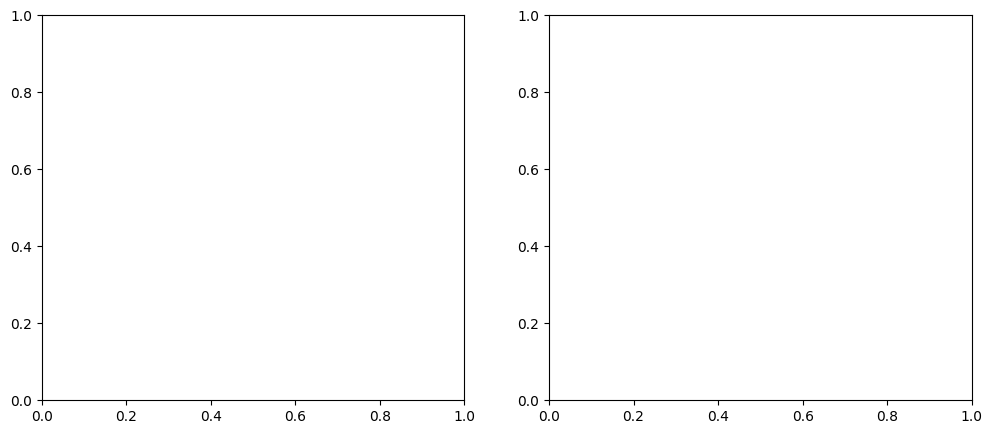

In [ ]:
# Plot how well LDA separates the 3-class problem as opposed to how PCA does #
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

w_lda = LDA(X_train, t_train)
Y_lda_train = X_train @ w_lda

# PCA plot
sc1 = axes[0].scatter(Y_pca_train[:,0], Y_pca_train[:,1], c=t_train, cmap='tab10', s=5)
axes[0].set_title("PCA 2D Projection")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], ticks=range(10))

# LDA plot
sc2 = axes[1].scatter(Y_lda_train[:,0], Y_lda_train[:,1], c=t_train, cmap='tab10', s=5)
axes[1].set_title("LDA 2D Projection")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
plt.colorbar(sc2, ax=axes[1], ticks=range(10))

plt.tight_layout()
plt.show()

# Because this is a partner project, you MUST list below who did what on the project to ensure equal contribution:

### Partner A (Dyl Nebrida):
1. Problem B
2. 
3. 

### Partner B (Jonathan Brown):
1. Problem A
2. Problem C
3. 

## CSC 548 Only!

**Problem D (10pts)**
* In class we discussed the when dealing with image data, the image vectors can be extremely larde and there computing the covariance matrix becomes intractable.  We also "claimed" that we could instead use the Singular Value Decomposition to provide the appropriate PCA subspace.  Show $\textbf{mathimatically}$ that this is indeed true.  That is, given the covariance matrix:
$$
    C = \frac{1}{n-1} X X^T
$$
show that for the eigenvalue decomposition
$$
    C \textbf{v} = \lambda \textbf{v}
$$
the eigenvectors $\textbf{v}$ are exactly the left-sigular vectors of $SDV(X)$ and that the eigenvalues $\lambda$ are exactly the square-root of the singular values $\sigma$ of $SVD(X)$.



<ins>*Solution:*</ins>